<a href="https://colab.research.google.com/github/shadmanr1/Milestone_1/blob/main/Week_9_Notebook_Shadman_Raakin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

# Dataset: Movie Box office (2000-2024)
General overview of the dataset is that it provides a detailed analysis of global box office performance from 2000 to 2024. It includes information on movies released during this period, covering key metrics such as release dates, genres, production budgets, worldwide gross, and more. The dataset aims to assist researchers, data scientists, and movie enthusiasts in exploring trends in the film industry, analyzing profitability, and understanding audience preferences over the years.
https://www.kaggle.com/datasets/aditya126/movies-box-office-dataset-2000-2024?select=enhanced_box_office_data%282000-2024%29u.csv

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving enhanced_box_office_data(2000-2024)u.csv to enhanced_box_office_data(2000-2024)u.csv


In [ ]:
df = pd.read_csv("enhanced_box_office_data(2000-2024)u.csv")

## Clean Rating Variable
Since this column contains values like "7/10, 8/10" etc. It would be easier to get rid of the /10 part.

In [ ]:
df["Rating_num"] = pd.to_numeric(df["Rating"].astype(str).str.extract(r"([0-9.]+)")[0],errors="coerce")

Before moving forward, we'll be examining the worldwide revenue, since that is the main target variable.

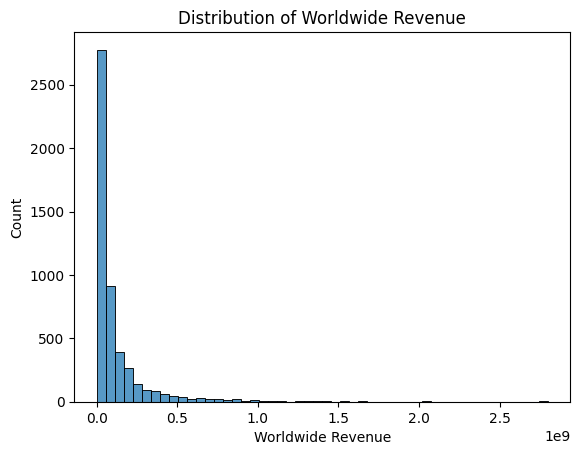

In [ ]:
sns.histplot(df["$Worldwide"], bins=50)
plt.title("Distribution of Worldwide Revenue")
plt.xlabel("Worldwide Revenue")
plt.show()

As noted in previous notebooks, the revenue is strongly right skewed since a small number of movies are blockbuster hits, and have earned tremendously more than the others. Due to this, we'll take the log of the revenue:

In [ ]:
df["Log_Worldwide"] = np.log1p(df["$Worldwide"])

Choosing predictors/feautres:

In [ ]:
features = ["Year","Genres","Rating_num","Vote_Count","Original_Language","Production_Countries"]
target = "Log_Worldwide"
numeric_features = ["Year","Rating_num","Vote_Count"]
categorical_features = ["Genres","Original_Language","Production_Countries"]

## Train/split
Here, we'll do a time based split, because the data spans from 2000-2024, training on older movies and testing on newed movies would be more realistic than a random split. The cutoff will be 2019.

In [ ]:
train = df[df["Year"] <= 2019].copy()
test = df[df["Year"] >= 2020].copy()
X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]
print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 4000
Testing observations: 1000


Preprecessing the predictors:

In [ ]:
numeric_transformer = Pipeline([("imputer", SimpleImputer(strategy="median"))])
categorical_transformer = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),("encoder", OneHotEncoder(handle_unknown="ignore",min_frequency=5,sparse_output=False))])
preprocessor = ColumnTransformer([("numeric", numeric_transformer, numeric_features),("categorical", categorical_transformer, categorical_features)])

##Fitting Graident boost:

In [ ]:
gradient_boost_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    min_samples_leaf=10,
    subsample=0.8,
    loss="huber",
    random_state=42
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", gradient_boost_model)
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Year', 'Rating_num',
                                                   'Vote_Count']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 min_frequency=5,
                                                                                 sparse_output=False))]),
                                                  ['Genres',
                                                   'Original_Language',
                                                   'Production_Countries'])])),
                ('regressor',
                 GradientBoostingRegressor(learning_rate=0.03, loss='huber',
                                           min_samples_leaf=10,
                                           n_estimators=300, random_state=42,
                                           subsample=0.8))])

Afterwards, we'll evaluate the model:

In [ ]:
log_predictions = model.predict(X_test)
predictions = np.expm1(log_predictions)

actual = test["$Worldwide"]

mae = mean_absolute_error(actual, predictions)
rmse = np.sqrt(mean_squared_error(actual, predictions))
r2 = r2_score(actual, predictions)

print(f"MAE:  ${mae:,.0f}")
print(f"RMSE: ${rmse:,.0f}")
print(f"R²:   {r2:.3f}")

MAE:  $71,839,021
RMSE: $174,356,766
R²:   0.239


Results show that:

A simple model that always predicts the training median had:

MAE: approximately 87.5 million dollars

RMSE: approximately 202.7 million dollars

R²: −0.029

Therefore, Gradient Boosting performs much better than the baseline

Model of the Actual vs Predicted:

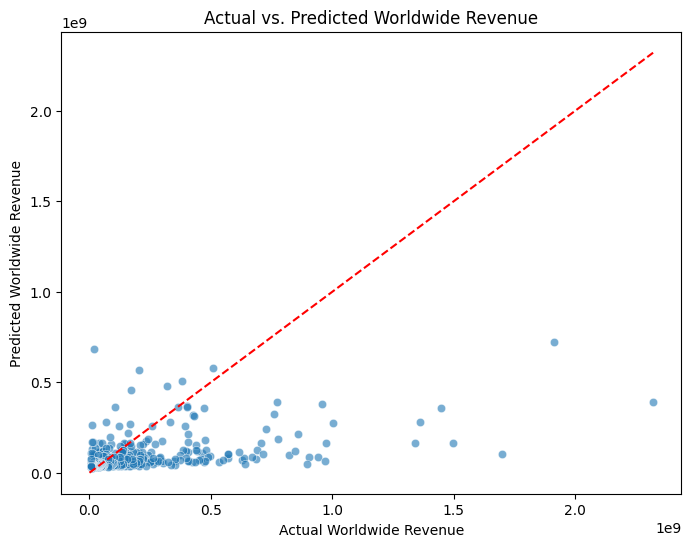

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=actual,
    y=predictions,
    alpha=0.6
)

maximum = max(actual.max(), predictions.max())
plt.plot([0, maximum], [0, maximum], "r--")

plt.xlabel("Actual Worldwide Revenue")
plt.ylabel("Predicted Worldwide Revenue")
plt.title("Actual vs. Predicted Worldwide Revenue")
plt.show()

In conclusion, a Gradient Boosting regression model was used to estimate worldwide box office revenue based on release year, genre, rating, vote count, original language, and production country. Worldwide revenue was log transformed because its distribution was strongly right skewed. Movies released from 2000 through 2019 were used for training, while movies released from 2020 through 2024 were reserved for testing. The model had an R² of approximately 0.239 and a mean absolute error of approximately $71.8 million. Although prediction errors are still substantial, Gradient Boosting outperformed a median-revenue baseline, indicating that the selected movie characteristics contain good information about box office performance.